### Simple Multiagent Architect

In [11]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from typing_extensions import Annotated,List,Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END,MessagesState
from langgraph.prebuilt import create_react_agent,ToolNode
from langgraph.checkpoint.memory import MemorySaver
load_dotenv()

True

In [12]:
os.environ['GROQ_API_KEY'] =os.getenv('GROQ_API_KEY')

In [13]:
class AgentState(MessagesState):
    next_agent :str # which agent should go agent

In [14]:
# create simple tool
@tool
def search_web(query:str)->str:
    """search the web information using tavily search
    """
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content:str)->str:
    """Write the summary of the provided content
    simple summary ganerated"""
    summary = f"Summary of the findings :\n\n{content[:500]}...."
    return summary

In [15]:
llm = ChatGroq(model = "qwen/qwen3.8-27b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, client=<groq.resources.chat.completions.Completions object at 0x74d1ae86a710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x74d1ae86b110>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [16]:
def reseacher_agent(state:AgentState):
    """Research agent that search for the information"""
    
    messages = state['messages']
    
    # add system messages for context
    system_msg = SystemMessage(content="You are a research assistant. use the search_web to to find information of the user request")
    
    # Call LLM with tools
    reseacher_llm= llm.bind_tools([search_web])
    resonse = reseacher_llm.invoke([system_msg] +messages)
    
    # Return the response and route to writer
    return {
        "messages":[resonse],
        "next_agent":"writer"
        
    }

In [17]:
def writer_agent(state:AgentState):
    
    messages= state['messages']
    
    # add the system message
    system_msg = SystemMessage(content="you are a technical writer. review the conversation and create a clear, concise summary of the finding")
    
    #Simple completion without tools
    response = llm.invoke([system_msg]+messages)
    
    return {
        "messages":[response],
        "next_agent":"end"
    }

In [18]:
# tool executor node

def execute_tools(state:AgentState):
    """Execute any panding tool calls"""
    messages = state['messages']
    
    last_message = messages[-1]
    
    # check if there are tool calls to execute
    if hasattr(last_message,"tool_calls") and last_message.tool_calls:
        # create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        
        return response
    
    # No tools to execute
    return state

In [19]:
# #========================================
# # Minimal working Example with real llm
# #========================================

# def create_minimal_agent():
#     """Minimal multi-agent system using just llm calls
#     """
    
#     def researcher_node(state:MessagesState):
#         """Simple researcher using just llm"""
#         messages= state['messages']
        
#         # Create prompt for researcher
#         prompt =[
#             SystemMessage(content="you are a researcher. analyze the user's question and provide detail"),
#             *messages
#         ]
        
#         # Get response
#         response= llm.invoke(prompt)
        
#         return {"messages":[response]}
    
    
#     def write_node(state:MessagesState):
#         "Simple writer using just llm"
#         messages = state['messages']
        

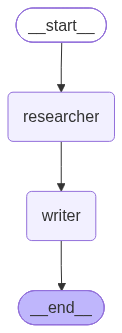

In [20]:
# build graph
workflow = StateGraph(MessagesState)

# add nodes
workflow.add_node("researcher",reseacher_agent)
workflow.add_node("writer",writer_agent)

# define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher",'writer')
workflow.add_edge("writer",END)
final_workflow =workflow.compile()
final_workflow

In [21]:
respose = final_workflow.invoke({'messages':"what is use case of ai in the business"})
respose

{'messages': [HumanMessage(content='what is use case of ai in the business', additional_kwargs={}, response_metadata={}, id='b9e19df2-d8a2-4c96-8e98-e111afc2b069'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nymhhpfrb', 'function': {'arguments': '{"query":"use cases of AI in business 2024 2025"}', 'name': 'search_web'}, 'type': 'function'}, {'id': '2g7m7sgfh', 'function': {'arguments': '{"query":"artificial intelligence business applications examples"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 300, 'total_tokens': 370, 'completion_time': 0.218508903, 'completion_tokens_details': None, 'prompt_time': 0.020394745, 'prompt_tokens_details': None, 'queue_time': 0.047954154, 'total_time': 0.238903648}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run

In [23]:
print(respose['messages'][-1].content)

Based on current industry trends and applications, here is a summary of the key use cases of Artificial Intelligence (AI) in business:

### 1. Customer Service & Experience
*   **Intelligent Chatbots & Virtual Assistants:** Provide 24/7 automated customer support, handling common queries, troubleshooting, and routing complex issues to human agents.
*   **Personalization:** AI analyzes customer data to deliver personalized product recommendations, content, and marketing offers, increasing engagement and conversion rates.
*   **Sentiment Analysis:** Monitors social media and customer feedback to gauge brand sentiment and identify potential issues in real-time.

### 2. Marketing & Sales
*   **Predictive Analytics:** Forecasts customer behavior, churn risk, and sales trends to help sales teams prioritize leads and optimize outreach.
*   **Content Generation:** Uses generative AI to create marketing copy, ad variations, social media posts, and email campaigns at scale.
*   **Dynamic Pricing